# Custom gradients · register your own imaging condition

Replace PyTorch's autograd gradient with a user-supplied imaging condition:

```python
prop.register_gradient('vp', lambda fwd, adj, models, dt, dh: fwd['h1'] * adj['h1'])
```

- **fn signature** `fn(forward, adjoint, models, dt, dh)` — `forward[name]` is
  a snapshot of the forward wavefield at time t; `adjoint[name]` is what
  PyTorch's reverse pass delivers as `∂loss/∂forward[name]`, i.e. the true
  adjoint wavefield. Both are dicts; the keys come from `imaging_type=[...]`
  (defaults to `[source_type[0]]`).
- **two modes**
  - `mode='gradient'` — after `loss.backward()` your formula's output becomes
    `vp.grad`; drop-in for `torch.optim`.
  - `mode='imaging'` — produced only by `prop.imaging(...)` as an image dict;
    `vp.grad` untouched.

Eager backend only (`impl='eager'`). No external data.


## 1. Setup — a two-layer acoustic problem

In [1]:
import sys, pathlib
# Prepend worktree src/ so `import sweep` picks up this branch's code
_repo = pathlib.Path().resolve().parents[1]  # examples/notebooks/ -> repo root
if str(_repo / 'src') not in sys.path:
    sys.path.insert(0, str(_repo / 'src'))

import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (96, 128)
dh, dt, nt = 10.0, 0.002, 600
freq, delay = 10.0, 0.12
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [2]:
vp_true = np.full(shape, 1500.0, dtype=np.float32)
vp_true[shape[0] // 2:, :] = 2500.0
vp_init = np.full(shape, 1500.0, dtype=np.float32)

equation = Acoustic(device=device)
solver = PropTorch(equation, shape=shape, dh=dh, dt=dt, dev=device,
                   use_ckpt=False, impl='eager')

t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq).astype(np.float32)
sources = np.array([[shape[1] // 2, 2]], dtype=np.int64)
rec_x = np.linspace(0, shape[1] - 1, 64, dtype=np.int64)
receivers = np.stack([rec_x, np.full_like(rec_x, 4)], axis=1)[None]

with torch.no_grad():
    obs = solver(wavelet, sources, receivers,
                 models=[torch.tensor(vp_true, device=device)])
print('obs shape:', tuple(obs.shape))

obs shape: (1, 600, 64, 1)


### Which wavefields can my fn access?

Ask the propagator — the names below are the valid dict keys for `forward[...]`
and `adjoint[...]`. Pass any subset via `imaging_type=[...]`; omit it for the
single-key shortcut `{source_type[0]: tensor}`.


In [3]:
print('wavefield_names :', solver.wavefield_names)
print('source_type     :', solver.source_type,
      '  ← wavelet is injected into this field')
print('receiver_type   :', solver.receiver_type,
      '  ← receiver records are read from this field')
print()
default_key = solver.wavefield_names[solver.source_indices[0]]
print(f'When imaging_type=None (default), fn gets a single-key dict')
print(f'    forward[{default_key!r}] / adjoint[{default_key!r}]')
print('To expose more, pass e.g. imaging_type=["h1", "psix"]'
      ' (any subset of wavefield_names).')


wavefield_names : ['h1', 'h2', 'psix', 'psiz', 'zetax', 'zetaz']
source_type     : ['h1']   ← wavelet is injected into this field
receiver_type   : ['h1']   ← receiver records are read from this field

When imaging_type=None (default), fn gets a single-key dict
    forward['h1'] / adjoint['h1']
To expose more, pass e.g. imaging_type=["h1", "psix"] (any subset of wavefield_names).


## 2. Baseline — default autograd gradient

`loss.backward()` with nothing registered → PyTorch's autograd grad. Reference
for the next sections.


In [4]:
def cosine(a, b):
    a, b = a.flatten().astype(np.float64), b.flatten().astype(np.float64)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30))

vp_t = torch.tensor(vp_init, device=device, requires_grad=True)
pred = solver(wavelet, sources, receivers, models=[vp_t])
loss = 0.5 * (pred - obs).pow(2).sum()
loss.backward()
g_autograd = vp_t.grad.detach().cpu().numpy()
print('autograd grad: norm=%.4e' % np.linalg.norm(g_autograd))

autograd grad: norm=2.7581e-03


## 3. `register_gradient` — gradient mode

Register the **standard acoustic imaging condition**
`2·dt²·vp·∇²(forward['h1'])·adjoint['h1']` (the continuous-adjoint formula for
`∂L/∂vp`). It tracks PyTorch's autograd grad closely (cosine ≈ 1); the small
gap is analytic-formula vs differentiating-the-discrete-forward.


In [5]:
def standard_imaging(forward, adjoint, models, dt, dh):
    vp = models[0]
    hz, hx = equation._spacings_2d(dh)
    lz, lx = equation.separable_d2_2d(forward['h1'], equation.laplace_kernels, hz, hx)
    return 2.0 * dt * dt * vp * (lz + lx) * adjoint['h1']

solver.register_gradient('vp', standard_imaging, mode='gradient')

vp_t = torch.tensor(vp_init, device=device, requires_grad=True)
pred = solver(wavelet, sources, receivers, models=[vp_t])
loss = 0.5 * (pred - obs).pow(2).sum()
loss.backward()
g_std = vp_t.grad.detach().cpu().numpy()
print('registered std grad: norm=%.4e' % np.linalg.norm(g_std))
print('cosine vs autograd  = %.4f   (≈ 1 → same gradient)' % cosine(g_std, g_autograd))


registered std grad: norm=2.7527e-03
cosine vs autograd  = 0.9909   (≈ 1 → same gradient)


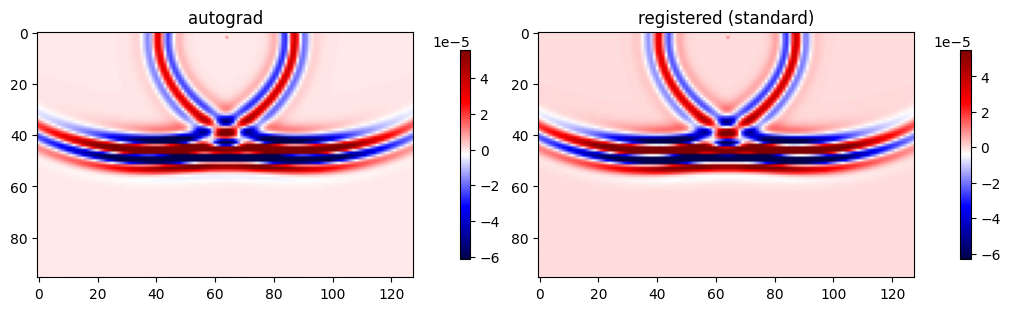

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
for ax, g, name in zip(axes, [g_autograd, g_std], ['autograd', 'registered (standard)']):
    vmin, vmax = np.percentile(g, [2, 98])
    im = ax.imshow(g, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(name); fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

### A different formula — zero-lag cross-correlation

Skip the Laplacian and the `2·dt²·vp` factor — `forward['h1'] · adjoint['h1']`
is a different image (not `∂L/∂vp` any more), useful as a raw RTM
cross-correlation.


forward['h1'] * adjoint['h1'] grad: norm=1.6998e+02   cosine vs autograd=-0.8478 (≠ 1, a distinct image)


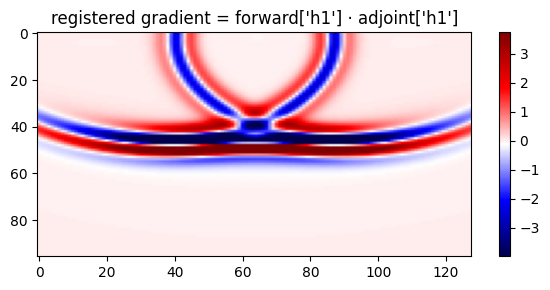

In [7]:
solver.clear_gradients()
solver.register_gradient('vp', lambda fwd, adj, m, dt, dh: fwd['h1'] * adj['h1'], mode='gradient')

vp_t = torch.tensor(vp_init, device=device, requires_grad=True)
pred = solver(wavelet, sources, receivers, models=[vp_t])
loss = 0.5 * (pred - obs).pow(2).sum()
loss.backward()
g_xcorr = vp_t.grad.detach().cpu().numpy()
print("forward['h1'] * adjoint['h1'] grad: norm=%.4e   cosine vs autograd=%.4f (≠ 1, a distinct image)"
      % (np.linalg.norm(g_xcorr), cosine(g_xcorr, g_autograd)))

vmin, vmax = np.percentile(g_xcorr, [2, 98])
plt.figure(figsize=(6, 3))
plt.imshow(g_xcorr, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.title("registered gradient = forward['h1'] · adjoint['h1']")
plt.colorbar(); plt.tight_layout(); plt.show()


## 4. `mode='imaging'` — diagnostic image, `vp.grad` untouched

`prop.imaging()` runs the same forward-with-hooks, then triggers the reverse
pass *internally* with `pred.backward(gradient=adj_src)` — `pred` is the
receiver synthetic the propagator produces (same thing `prop(wavelet, ...)`
returns). What `adj_src` is — i.e. **what implicit loss** is being
differentiated — depends on the argument you pass:

| Call | `adj_src` | Implicit loss |
|---|---|---|
| `imaging(observed=obs)` | `pred − obs` | $L = \tfrac12\,\lVert \text{pred}-\text{obs}\rVert^2$ ← **standard L2 / RTM** |
| `imaging(adjoint_source=A)` | `A` | whatever has `∂L/∂pred = A` |
| `imaging(...)` (neither) | `pred` | $L = \tfrac12\,\lVert \text{pred}\rVert^2$ (autocorrelation; sanity check only) |

Below we run the first flavour but on the *same* true model that produced
`obs`, so `pred − obs ≈ 0` and the image is near-empty — this is just an API
smoke test. Real RTM = forward on TRUE → `obs`, image on SMOOTH background
→ see `16_adcig.ipynb` for the full flow.


imaging keys: ['vp']
vp.grad is None (untouched): True


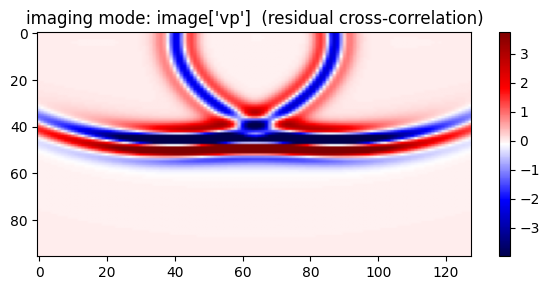

In [8]:
solver.clear_gradients()
solver.register_gradient('vp', lambda fwd, adj, m, dt, dh: fwd['h1'] * adj['h1'], mode='imaging')

vp_t = torch.tensor(vp_init, device=device, requires_grad=True)
images = solver.imaging(wavelet, sources, receivers, models=[vp_t], observed=obs)
img = images['vp'].detach().cpu().numpy()
print('imaging keys:', list(images.keys()))
print('vp.grad is None (untouched):', vp_t.grad is None)

vmin, vmax = np.percentile(img, [2, 98])
plt.figure(figsize=(6, 3))
plt.imshow(img, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.title("imaging mode: image['vp']  (residual cross-correlation)")
plt.colorbar(); plt.tight_layout(); plt.show()
